In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.linear_model import LinearRegression

## Загружаем данные

In [2]:
df = pd.read_csv("./data/data.csv", sep=";", decimal=",")

In [3]:
df_without_gaps = df[df["x4"] != " "].copy()

# Месяцы
months = df_without_gaps["date1"]

# Год
years = df_without_gaps["date2"]

time_series = df_without_gaps['x4'].astype(str).str.replace(',', '.').astype(float)

Посмотрим на график средней цены номера.

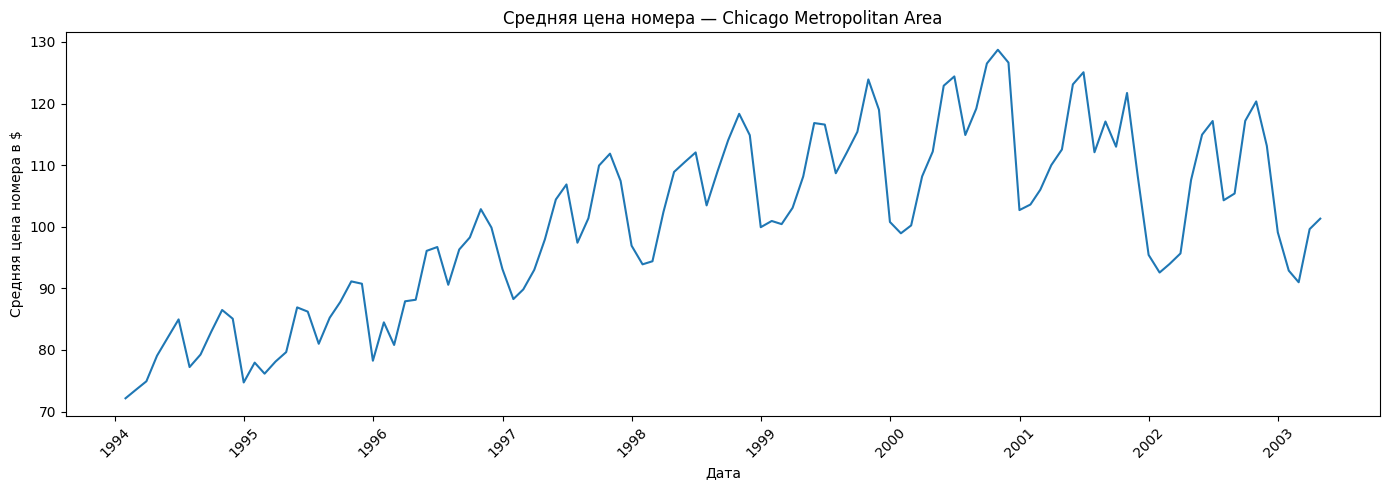

In [4]:
df_without_gaps['date'] = pd.date_range(start='1994-01', periods=len(df_without_gaps), freq='ME')

plt.figure(figsize=(14, 5))
sns.lineplot(x=df_without_gaps['date'] , y=time_series)

plt.title('Средняя цена номера — Chicago Metropolitan Area')
plt.xlabel('Дата')
plt.ylabel('Средняя цена номера в $')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
seasonal_decomposition_result = seasonal_decompose(time_series, model="multiplicative", period=12)
seasonal_decomposition_result

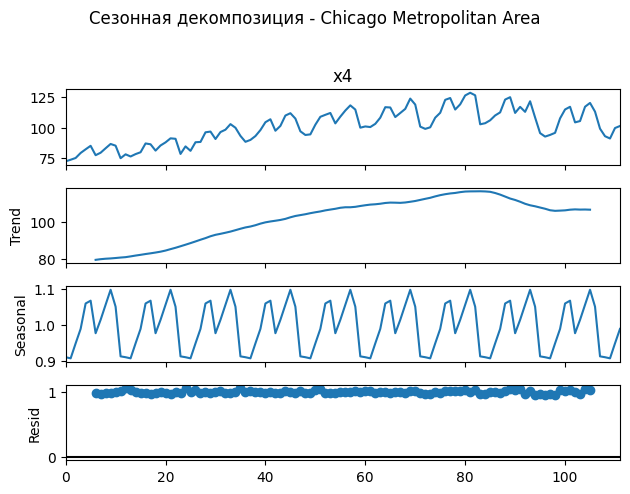

In [6]:
fig = seasonal_decomposition_result.plot()
fig.suptitle('Сезонная декомпозиция - Chicago Metropolitan Area', y=1.02)
plt.tight_layout()

### Посмотрим отдельно на тренд

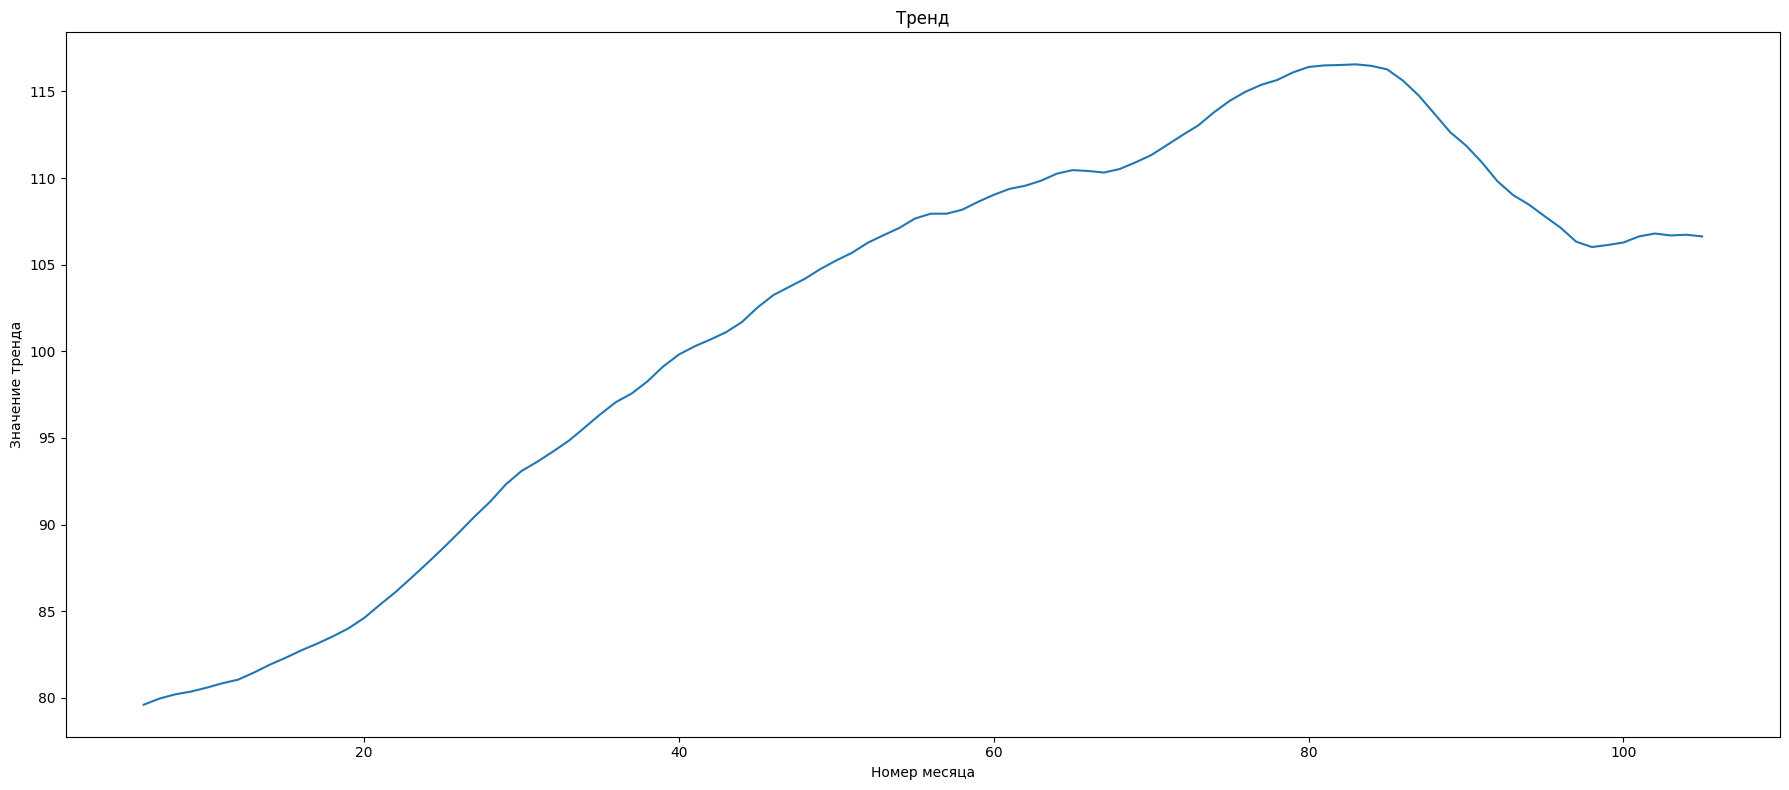

In [7]:
plt.figure(figsize=(18, 8))
seasonal_decomposition_result.trend.plot()
plt.xlabel('Номер месяца')
plt.ylabel('Значение тренда')
plt.title("Тренд")
plt.tight_layout()

### Посмотрим отдельно на сезонность

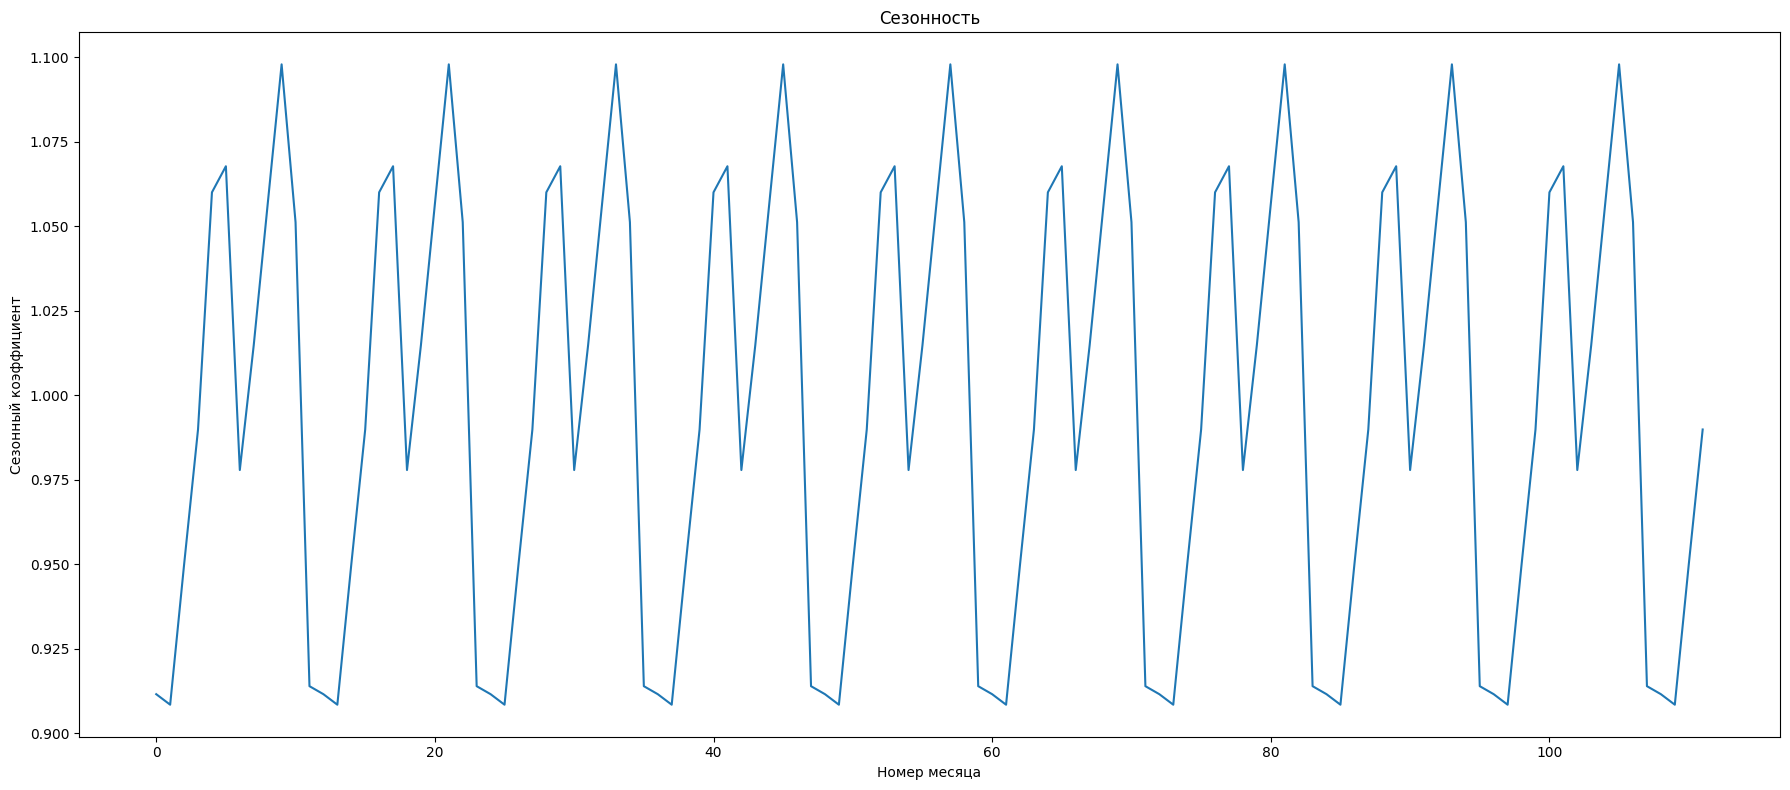

In [8]:
plt.figure(figsize=(18, 8))
seasonal_decomposition_result.seasonal.plot()
plt.xlabel('Номер месяца')
plt.ylabel('Сезонный коэффициент')
plt.title("Сезонность")
plt.tight_layout()

### Посмотрим отдельно на остатки

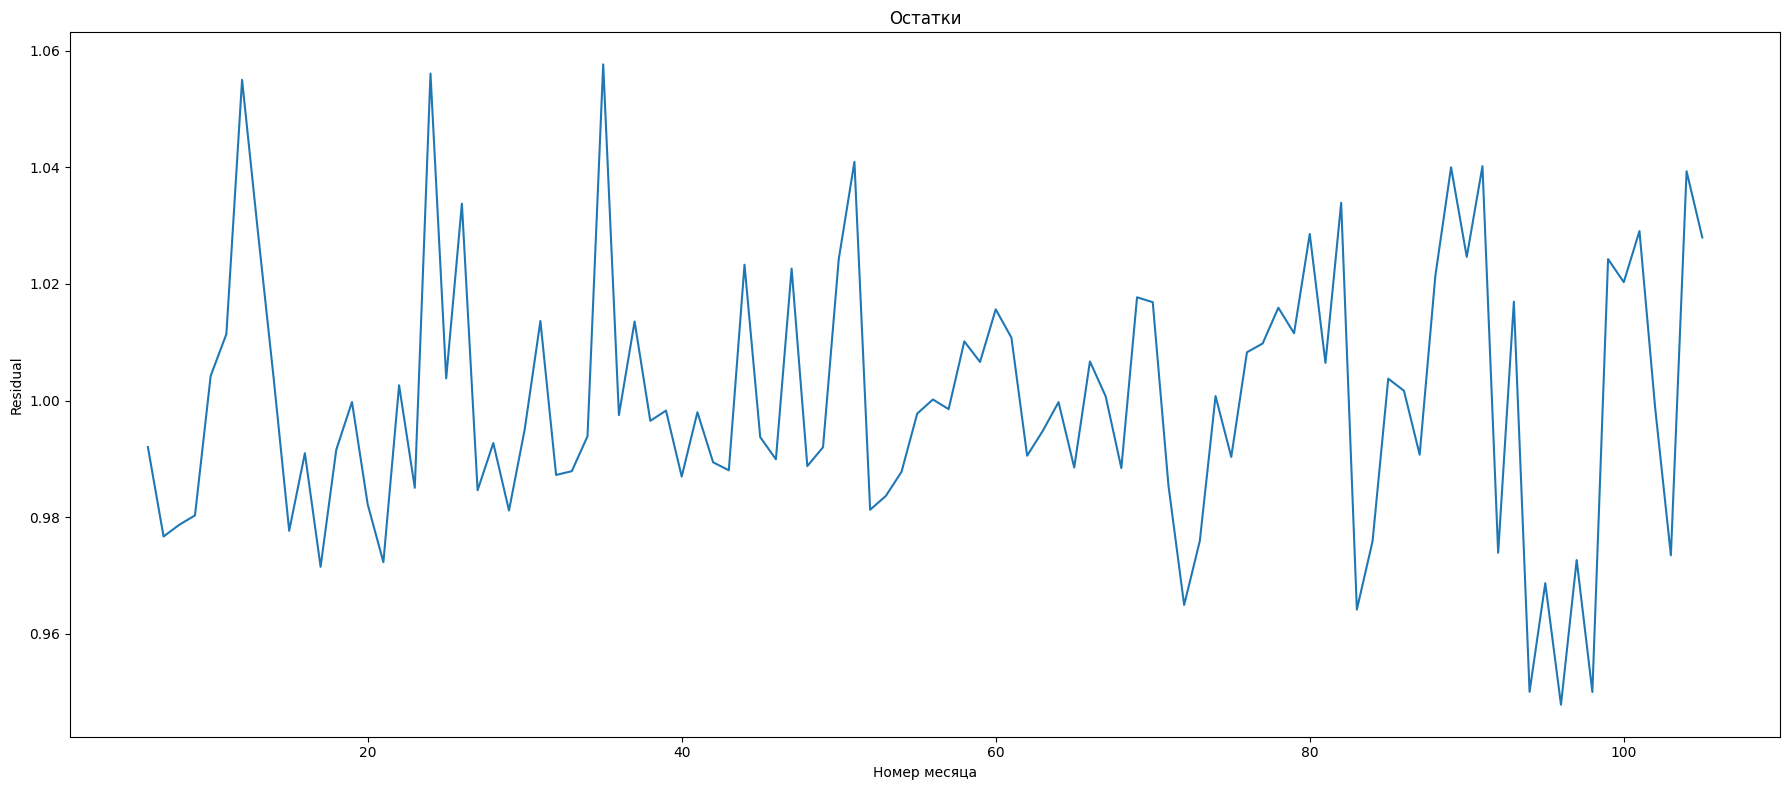

In [9]:
plt.figure(figsize=(18, 8))
seasonal_decomposition_result.resid.plot()
plt.title("Остатки")
plt.xlabel('Номер месяца')
plt.ylabel('Residual')
plt.tight_layout()

- Наша декомпозиция приносит ошибки: как минимум 6 %.

### Очистим ряд от сезонности

In [10]:
time_series_without_seasonal = time_series / seasonal_decomposition_result.seasonal

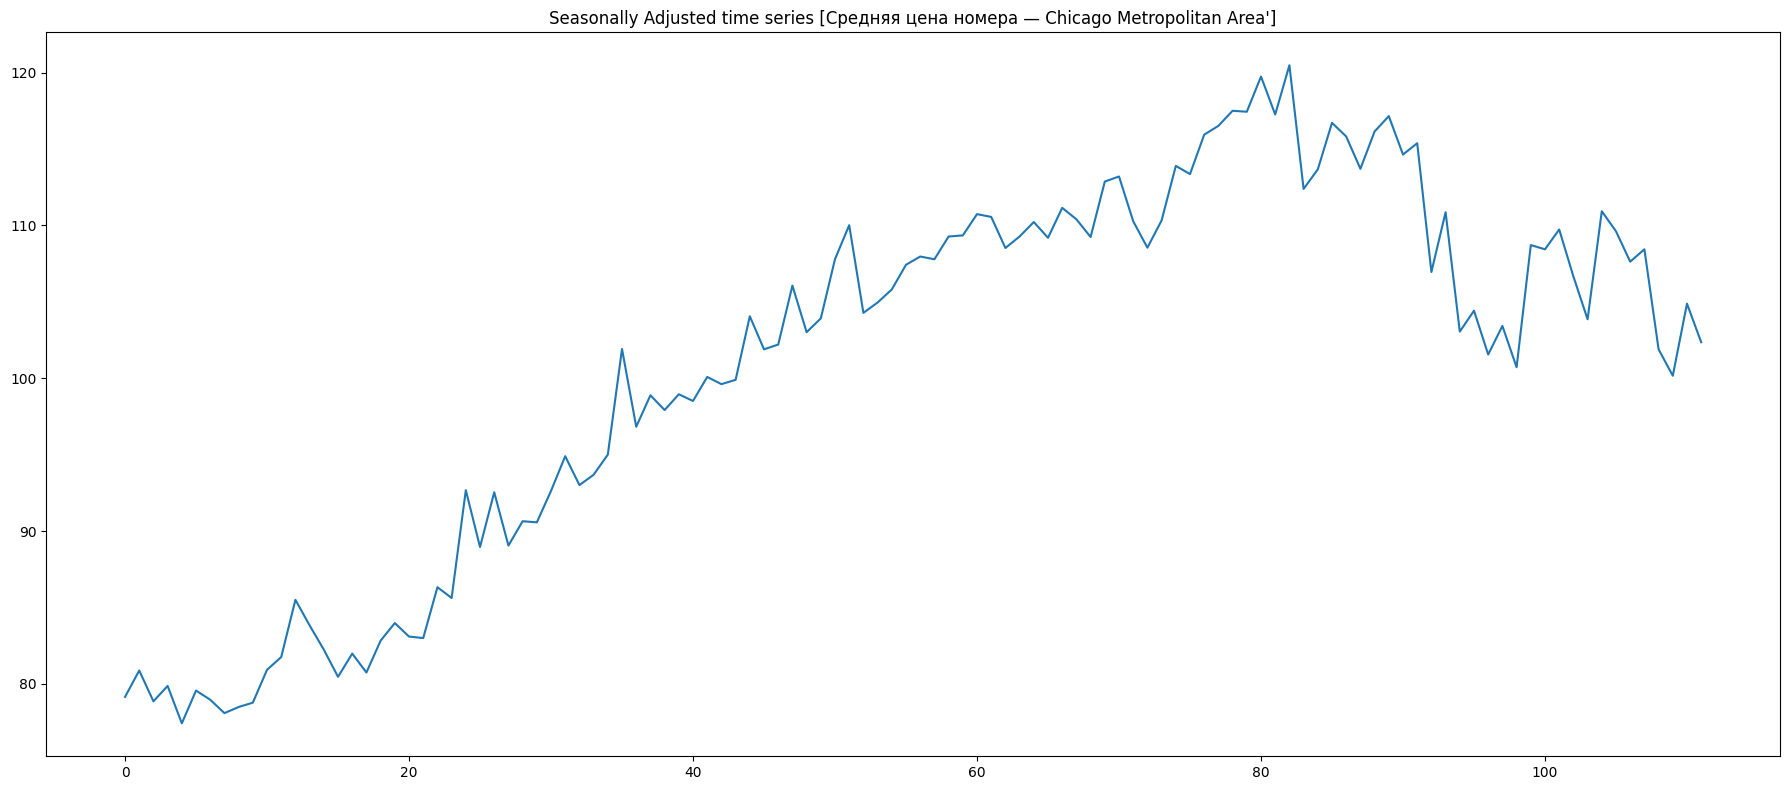

In [11]:
plt.figure(figsize=(18, 8))
time_series_without_seasonal.plot()
plt.title("Seasonally Adjusted time series [Средняя цена номера — Chicago Metropolitan Area']")
plt.tight_layout()

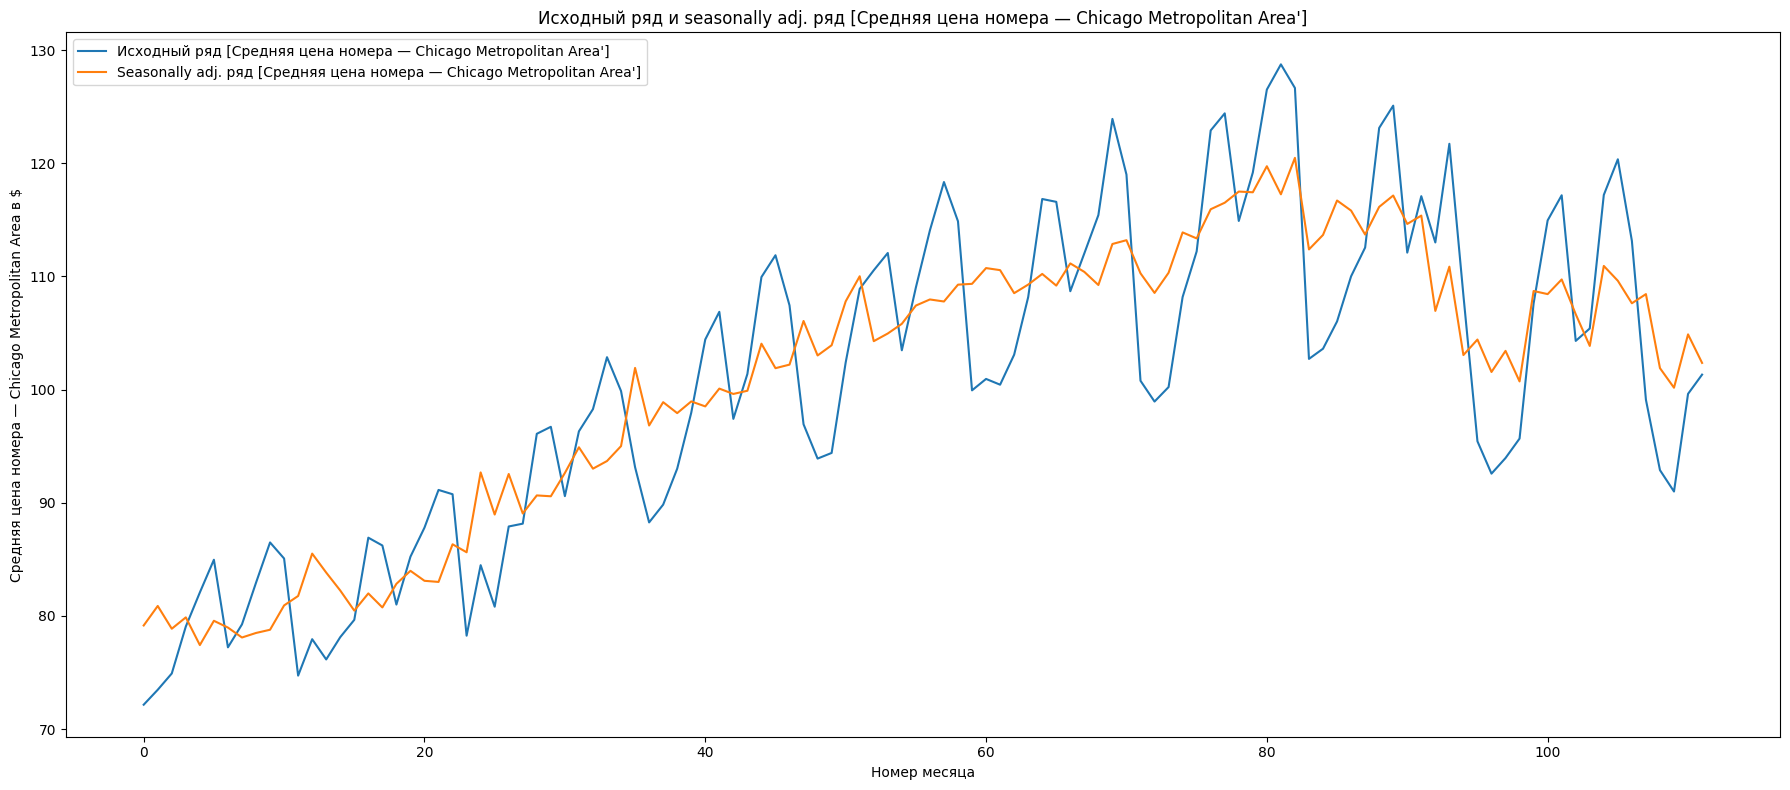

In [12]:
plt.figure(figsize=(18, 8))
plt.plot(time_series, label="Исходный ряд [Средняя цена номера — Chicago Metropolitan Area']")
plt.plot(time_series_without_seasonal, label="Seasonally adj. ряд [Средняя цена номера — Chicago Metropolitan Area']")
plt.legend(loc="best")

plt.title("Исходный ряд и seasonally adj. ряд [Средняя цена номера — Chicago Metropolitan Area']")
plt.xlabel('Номер месяца')
plt.ylabel('Средняя цена номера — Chicago Metropolitan Area в $')
plt.tight_layout()

### Строим прогноз

Посмотрим на кол-во пропусков.

In [13]:
seasonal_decomposition_result.trend.head(12)

0           NaN
1           NaN
2           NaN
3           NaN
4           NaN
5           NaN
6     79.599583
7     79.952500
8     80.197917
9     80.356250
10    80.582500
11    80.836667
Name: trend, dtype: float64

In [14]:
print(f"Всего пропусков: {seasonal_decomposition_result.trend.isna().sum()}")

Всего пропусков: 12


Всего у нас 12 пропусков.

Для расчета каждой точки тренда нужно по 6 наблюдений слева и 6 справа, поэтому теряется ровно по 6 точек в начале и по 6 точек в конце.

Удаляем NaN на краях тренда и нумеруем оставшиеся наблюдения начиная с 13, чтобы сохранить правильную временную позицию.

In [15]:
# Значения тренда без nan's
trend_without_nans = seasonal_decomposition_result.trend.dropna()

# Формируем новый DataFrame
new_trend_df = pd.DataFrame({
    "trend": trend_without_nans,
    "month_num": np.arange(13, 13 + len(trend_without_nans)),
}).reset_index().drop("index", axis=1)

# Вглянем на новый DataFrame
new_trend_df

,trend,month_num
0,79.599583,13
1,79.952500,14
2,80.197917,15
3,80.356250,16
4,80.582500,17
...,...,...
95,106.631250,108
96,106.797083,109
97,106.686667,110
98,106.727917,111


Попробуем рассмотреть для прогнозирования разные предикторы для линейной регрессии: month_num (номер месяца), month_num^2, month_num^3.

In [16]:
new_trend_df["month_num_squared"] = new_trend_df["month_num"] ** 2
new_trend_df["month_num_cubed"] = new_trend_df["month_num"] ** 3

Делим данные на таргет и разные наборы предикторов. Будем строить полиномиальные модели предсказания тренда.

In [17]:
# Таргет
y = new_trend_df["trend"]

# Первый вариант - используем только month_num
X1 = new_trend_df[["month_num"]]

# Второй вариант - используем month_num и month_num в квадрате
X2 = new_trend_df[["month_num", "month_num_squared"]]

# Третий вариант - используем month_num, month_num в квадрате, month_num в кубе
X3 = new_trend_df[["month_num", "month_num_squared", "month_num_cubed"]]

Попробуем спрогнозировать тренд используя полиномиальные регрессии. Обучим три модели и выберем на наш взгляд лучшую.

In [18]:
# Обучаем линейную регрессию на первом датасете фичей
first_model = LinearRegression().fit(X1, y)

# Обучаем линейную регрессию на втором датасете фичей
second_model = LinearRegression().fit(X2, y)

# Обучаем линейную регрессию на третьем датасете фичей
third_model = LinearRegression().fit(X3, y)

Посмотрим на коэффициенты для первой модели.

In [19]:
coef1 = pd.DataFrame(
    list(zip(
        ["intercept"] + X1.columns.tolist(), [first_model.intercept_] + first_model.coef_.tolist()
    )),
    columns=["predictor", "coef"]
)
coef1

,predictor,coef
0,intercept,80.427745
1,month_num,0.344538


Посмотрим на коэффициенты для второй модели.

In [20]:
coef2 = pd.DataFrame(
    list(zip(
        ["intercept"] + X2.columns.tolist(), [second_model.intercept_] + second_model.coef_.tolist()
    )),
    columns=["predictor", "coef"]
)
coef2

,predictor,coef
0,intercept,59.185359
1,month_num,1.208612
2,month_num_squared,-0.006913


Посмотрим на коэффициенты для третьей модели.

In [21]:
coef3 = pd.DataFrame(
    list(zip(
        ["intercept"] + X3.columns.tolist(), [third_model.intercept_] + third_model.coef_.tolist()
    )),
    columns=["predictor", "coef"]
)
coef3

,predictor,coef
0,intercept,73.520767
1,month_num,0.234657
2,month_num_squared,0.010958
3,month_num_cubed,-0.000095


Строим предсказания на trend.

In [22]:
dct = {
    "Полином первой степени": (first_model, X1),
    "Полином второй степени": (second_model, X2),
    "Полином третьей степени": (third_model, X3)
}

pred_results_dct = {key: value[0].predict(value[1]) for key, value in dct.items()}

pred_results_dct["Истинное значение таргета"] =  y

pred_results_df = pd.DataFrame(pred_results_dct)

Посмотрим на эти предсказания

Text(0.5, 1.0, 'Аппроксмация тренда с помощью полиномов')

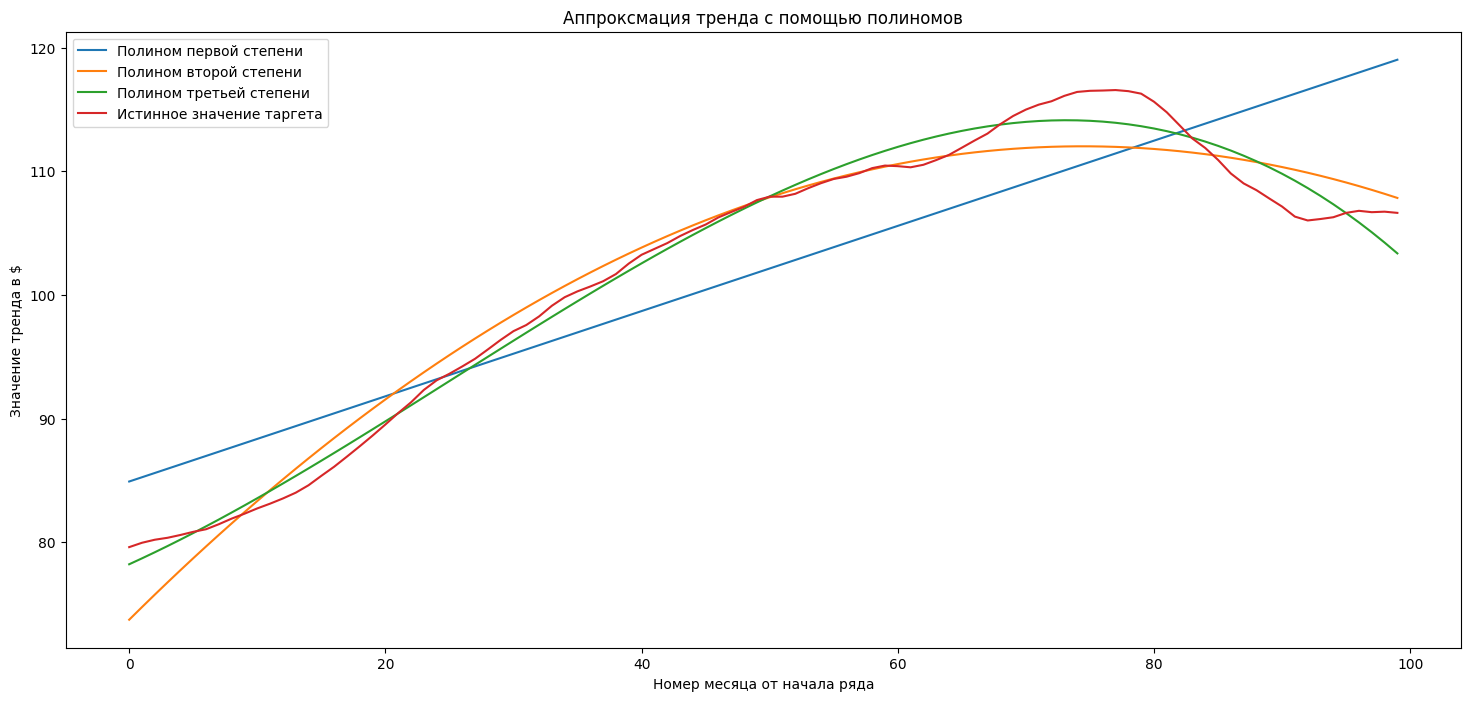

In [23]:
pred_results_df.plot(figsize=(18, 8))
plt.xlabel('Номер месяца от начала ряда')
plt.ylabel('Значение тренда в $')
plt.title('Аппроксмация тренда с помощью полиномов')

- Полином 1 степени выглядит слишком грубо, совершенно не улавливает изгиб тренда, уходит вверх когда данные падают.

- Полином 2 степени в целом хорошо следует общей форме: рост до примерно 80 наблюдения, затем плавный разворот вниз.

- Полином 3 степени немного переобучается: в самом конце резко уходит вниз, в отличие от истинного значения таргета.

**Вывод**: Выбираем полином 2 степени.

### Построим финальные предсказания

Вначале зададим номера следующих месяцев.

In [24]:
X_forestcast = pd.DataFrame(
    {
        "month_num": np.arange(new_trend_df["month_num"].iloc[-1] + 1, new_trend_df["month_num"].iloc[-1] + 1 + 8)
    }
)

# Добавим month_num^2

X_forestcast["month_num_squared"] = X_forestcast["month_num"] ** 2
X_forestcast

,month_num,month_num_squared
0,113,12769
1,114,12996
2,115,13225
3,116,13456
4,117,13689
5,118,13924
6,119,14161
7,120,14400


Строим предсказания пока без учета сезонности только для тренда.

In [25]:
forecast_without_seasonality = second_model.predict(X_forestcast)

Добавим в прогноз сезонные поправки.

In [26]:
forecast_with_seasonality = forecast_without_seasonality * seasonal_decomposition_result.seasonal.iloc[4:4+8].values
# forecast_with_seasonality = forecast_without_seasonality * seasonal_decomposition_result.seasonal.iloc[0:8].values
forecast_with_seasonality

array([113.94895741, 114.39372704, 104.39554761, 107.94991174,
       111.96079237, 115.8894252 , 110.507077  ,  95.66567877])

In [27]:
df_without_gaps['date'].iloc[-1]

Timestamp('2003-04-30 00:00:00')

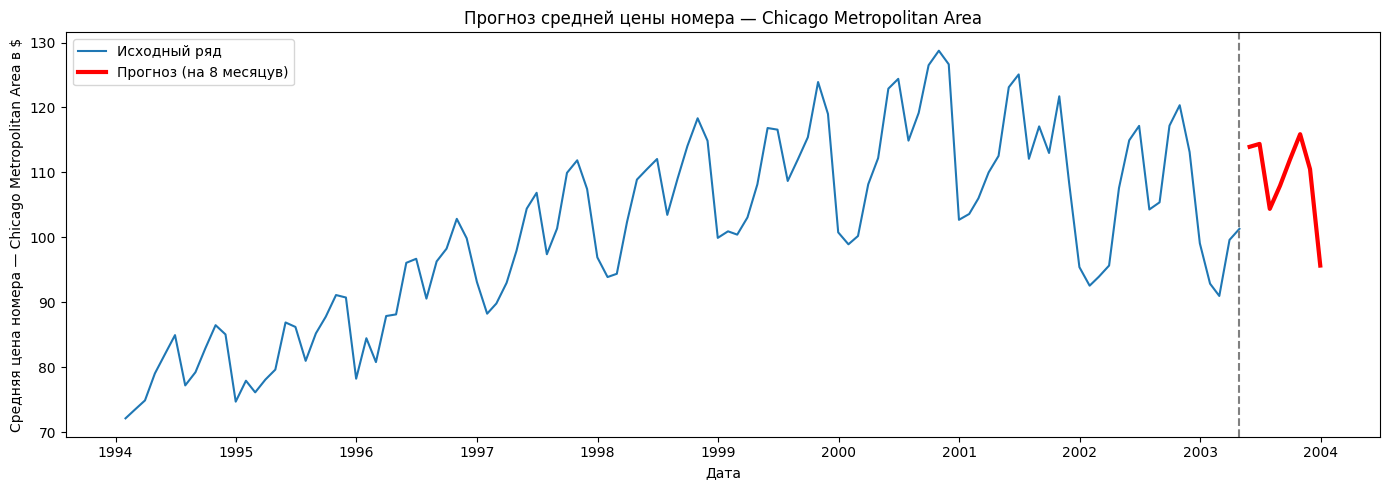

In [28]:
forecast_dates = pd.date_range(start='2003-05', periods=8, freq='ME')

plt.figure(figsize=(14, 5))
plt.plot(df_without_gaps['date'], time_series.values, label='Исходный ряд')
plt.plot(forecast_dates, forecast_with_seasonality, color='red', label='Прогноз (на 8 месяцув)', linewidth=3)
plt.axvline(x=df_without_gaps['date'].iloc[-1], color='gray', linestyle='--')
plt.title('Прогноз средней цены номера — Chicago Metropolitan Area')
plt.xlabel('Дата')
plt.ylabel('Средняя цена номера — Chicago Metropolitan Area в $')
plt.legend()
plt.tight_layout()
plt.show()

Результат логичен и учитывает сезонность.

- Цена на номера росла с 1994 по 2001 год, затем началось снижение - возможно связанное с событиями 11 сентября и последующим спадом туристического траффика.

- C точки зрения сезонности четко выражен повторяющийся годовой паттерн — пики приходятся на весенне-летний и осенний период, сильные спады в основном на зимние месяцы (январь–февраль, декабрь).

- Модель предсказывает цены в диапазоне от 95 до 120 примерно, cохраняет сезонность - пики весной и осенью и спад к зиме. Общий уровень цен ниже пиковых значений 2000–2001 годов, что соответствует нисходящему тренду после 2001 года.